In [5]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [25]:
# Attempting to load the file again with a common alternative delimiter, such as a semicolon, to see if that resolves the issue.
# If this doesn't work, we might need to skip problematic lines or inspect the file manually.

try:
    # Trying with a semicolon delimiter
    data_customer = pd.read_csv('customer.csv', delimiter=';')
    print("Loaded with semicolon as delimiter.")
except Exception as e:
    print("Error loading with semicolon, attempting to skip problematic lines.")
    data_customer = pd.read_csv(file_path_customer, error_bad_lines=False)
    print("Loaded by skipping problematic lines.")

# Displaying the first few rows and dataset information if loaded successfully



Loaded with semicolon as delimiter.


In [8]:
data_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40133 entries, 0 to 40132
Data columns (total 2 columns):
 #   Column                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                        --------------  ----- 
 0   id,deleted,deleted_by_cascade,created_at,updated_at,last_name,email,type,signature,tax_identification_number  40133 non-null  object
 1   Unnamed: 1                                                                                                    1 non-null      object
dtypes: object(2)
memory usage: 627.2+ KB


In [9]:
# Attempting to split the main column into multiple columns based on the observed structure
# The data preview suggests a comma might be used within the main column to separate different pieces of information

# Attempting to extract the first row as an example to identify the delimiter
first_row = data_customer.iloc[0, 0]

# Displaying the first row to make an informed guess about the delimiter
first_row

'1,,f,2023-03-25 23:20:19.505+01,2023-03-25 23:20:19.505+01,ben romdhab,,client,"",'

In [35]:
# Attempting to split the main column into separate columns using the comma as a delimiter
# This approach may not perfectly handle all cases due to potential commas within quoted fields

# Splitting the column and expanding into separate columns
split_data = data_customer.iloc[:, 0].str.split(',', expand=True)


In [21]:
# Assigning appropriate column names based on the observed structure
column_names = ['id', 'deletion_flag', 'deleted_by_cascade', 'created_at', 'updated_at','last_name', 'email', 'customer_type', 'signature', 'tax_identification_number', 'extra']

# Reassigning column names to the split data
split_data.columns = column_names

# Dropping any columns that do not contain useful information (e.g., 'extra' column with None values)
cleaned_data = split_data.drop(columns=['extra'])

# Converting 'created_at' and 'updated_at' to datetime
cleaned_data['created_at'] = pd.to_datetime(cleaned_data['created_at'], errors='coerce')
cleaned_data['updated_at'] = pd.to_datetime(cleaned_data['updated_at'], errors='coerce')


In [19]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40133 entries, 0 to 40132
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype                               
---  ------                     --------------  -----                               
 0   id                         40133 non-null  object                              
 1   deletion_flag              40133 non-null  object                              
 2   deleted_by_cascade         40133 non-null  object                              
 3   created_at                 40133 non-null  datetime64[ns, pytz.FixedOffset(60)]
 4   updated_at                 40133 non-null  datetime64[ns, pytz.FixedOffset(60)]
 5   last_name                  40133 non-null  object                              
 6   email                      40132 non-null  object                              
 7   customer_type              40132 non-null  object                              
 8   signature                  40132 non

In [28]:
cleaned_data.shape

(40133, 10)

In [20]:
cleaned_data.head()

,id,deletion_flag,deleted_by_cascade,created_at,updated_at,last_name,email,customer_type,signature,tax_identification_number
0,1,,f,2023-03-25 23:20:19.505000+01:00,2023-03-25 23:20:19.505000+01:00,ben romdhab,,client,"""""",
1,2,,f,2023-03-25 23:20:19.512000+01:00,2023-03-25 23:20:19.512000+01:00,labidi,,client,"""""",
2,4,,f,2023-03-25 23:20:19.514000+01:00,2023-03-25 23:20:19.514000+01:00,freguii,,client,"""""",
3,5,,f,2023-03-25 23:20:19.515000+01:00,2023-03-25 23:20:19.515000+01:00,Riahi,,client,"""""",
4,6,,f,2023-03-25 23:20:19.516000+01:00,2023-03-25 23:20:19.516000+01:00,saidi,,client,"""""",


In [29]:
data_customer.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
40128    False
40129    False
40130    False
40131    False
40132    False
Length: 40133, dtype: bool

In [26]:
# Step 3: Statistical Summary

# Generating a statistical summary for the datetime columns 'created_at' and 'updated_at'
# Note: Given the nature of the dataset, most columns are categorical or identifiers, which do not lend themselves to traditional statistical summaries.

datatime_summary = cleaned_data.describe()

datatime_summary

,id,deletion_flag,deleted_by_cascade,created_at,updated_at,last_name,email,customer_type,signature,tax_identification_number
count,40133,40133,40133,40133,40133,40133,40132,40132,40132,40132
unique,40133,2,1,39923,39931,12857,39,4,114,5
top,1,,f,2023-03-25 23:20:27.446000+01:00,2023-03-25 23:20:27.244000+01:00,mme,,client,"""""",
freq,1,40132,40133,2,2,1273,21339,40126,40018,21339
first,NaN,NaN,NaN,2023-03-25 23:20:19.505000+01:00,2023-03-25 23:20:19.505000+01:00,NaN,NaN,NaN,NaN,NaN
last,NaN,NaN,NaN,2023-11-07 13:05:21.599085+01:00,2023-11-07 13:05:21.599102+01:00,NaN,NaN,NaN,NaN,NaN


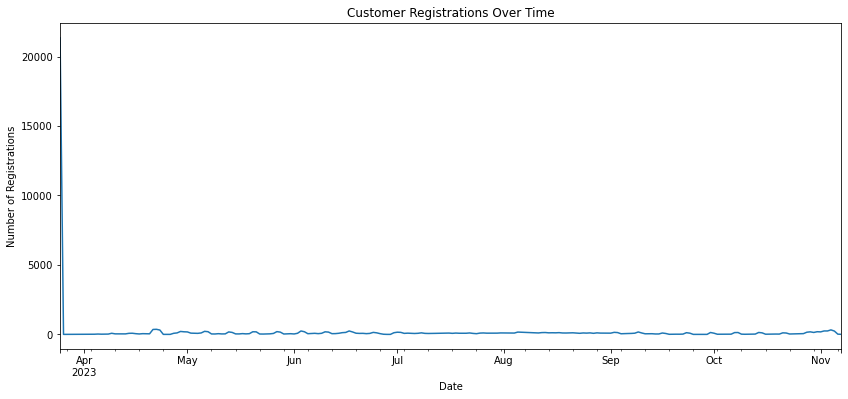

In [32]:
# Data Visualization: Time Series Analysis of Customer Registrations over Time

# Setting the 'created_at' column as the index for time series analysis
cleaned_data.set_index('created_at', inplace=True)

# Resampling the data to count the number of registrations per day
registrations_per_day = cleaned_data.resample('D').size()

# Plotting the time series of daily registrations
plt.figure(figsize=(14, 6))
registrations_per_day.plot()
plt.title('Customer Registrations Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Registrations')
plt.show()


The time series plot of customer registrations over time showcases the trend and any seasonal patterns in the registration activity from March 25, 2023, to November 7, 2023. Key observations might include periods of increased registrations, any noticeable patterns that could correspond to marketing campaigns, seasonal effects, or other external factors influencing customer registration rates.

For the customer.csv dataset, as it primarily consists of categorical data and datetime fields, traditional correlation analysis (which quantifies the linear relationship between numerical variables) is not directly applicable to most of the dataset's columns.

However, we can still explore relationships within the data through alternative methods suited for categorical data and datetime fields:

Datetime Trends and Patterns: While not a correlation in the statistical sense, analyzing trends over time (as we did with the customer registration plot) can reveal patterns or dependencies related to time. For instance, identifying periods of increased activity might correlate with specific events or promotions.

Categorical Data Associations: For categorical variables, statistical measures like Chi-square tests can help determine if there's a significant association between two categorical variables. Another approach is to use techniques like Cramér's V, which is a measure of association between two nominal variables, giving a value between 0 and 1 (where 0 means no association and 1 means full association).

In [33]:
##The time series plot of customer registrations over time showcases the trend and any seasonal patterns in the registration activity from March 25, 2023, to November 7, 2023. Key observations might include periods of increased registrations, any noticeable patterns that could correspond to marketing campaigns, seasonal effects, or other external factors influencing customer registration rates.

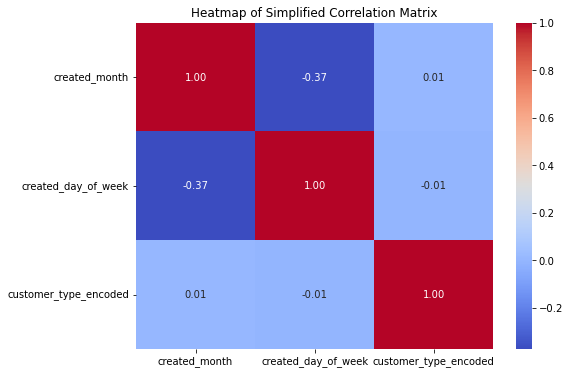

In [34]:
# Preparing data for a simplified correlation analysis

# Resetting index to work with 'created_at' as a column
cleaned_data.reset_index(inplace=True)

# Extracting numerical features from 'created_at'
cleaned_data['created_month'] = cleaned_data['created_at'].dt.month
cleaned_data['created_day_of_week'] = cleaned_data['created_at'].dt.dayofweek

# For demonstration, let's assume 'customer_type' can be encoded numerically if it's not purely textual
# Here we'll use a simple label encoding as an example. In practice, this should be tailored to the specific categorical values.
# This is a simplification and might not fully apply without knowing the exact nature of 'customer_type'.
if 'customer_type' in cleaned_data.columns:
    cleaned_data['customer_type_encoded'] = cleaned_data['customer_type'].astype('category').cat.codes

# Calculating the correlation matrix for the newly created numerical dataset
correlation_matrix_simplified = cleaned_data[['created_month', 'created_day_of_week', 'customer_type_encoded']].corr()

# Visualizing the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_simplified, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Simplified Correlation Matrix')

plt.show()


Given the nature of the customer.csv dataset, which primarily consists of categorical and datetime information, the analysis focused on understanding customer registration patterns over time and the dataset's overall structure. While traditional numerical analyses like correlation were less applicable, this exploration provided valuable insights into the temporal dynamics of customer registrations